The mouse placentation Stereo-seq data: [processed h5ad file with unspliced and spliced data](https://db.cngb.org/stomics/mpsta/download/).

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import seaborn as sns
import matplotlib.pyplot as plt
import STAVelo as stv
stv.settings.verbosity = 3
stv.settings.presenter_view = True
stv.set_figure_params("scvelo")
import warnings
warnings.filterwarnings("ignore")

# Read data

In [2]:
adata=sc.read("/mnt/disk3/lishang/data/Stereoseq_MPSTA_us/E7.5_S1.h5ad")

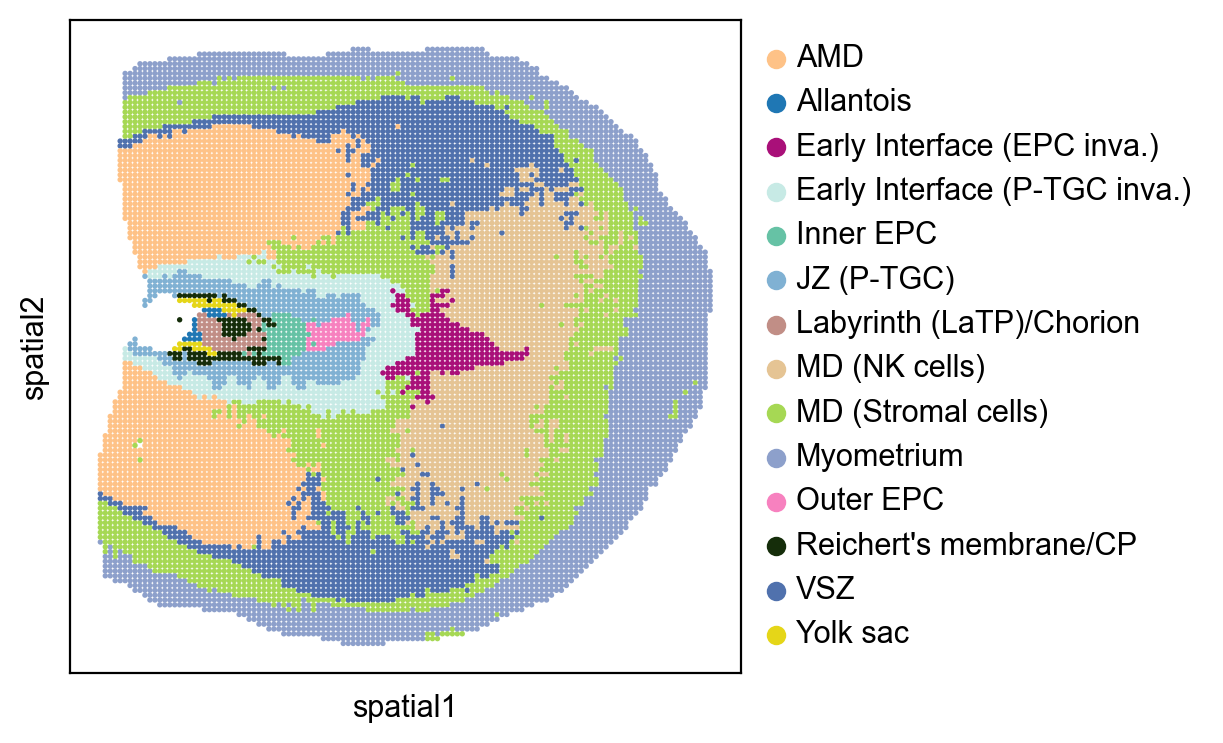

In [3]:
plt.rcParams["figure.figsize"] = (4.3, 4.3)
sc.pl.embedding(adata, basis="spatial", color="subregion", title="", s=15)

# Run model

In [4]:
stv.show_proportions(adata)
adata

Abundance of ['unspliced', 'spliced', 'ambiguous']: [0.03 0.97 0.  ]


AnnData object with n_obs × n_vars = 12568 × 18406
    obs: 'x', 'y', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subregion', 'interface', 'celltype1', 'subclusters_5_last', 'subregion5', 'region'
    var: 'n_cells_by_counts'
    uns: 'region_colors', 'subregion_colors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    layers: 'ambiguous', 'counts', 'matrix', 'spliced', 'unspliced'

In [5]:
stv.filter_and_normalize(adata, min_shared_counts=1, n_top_genes=1000)
stv.moments(adata, n_pcs=30, n_neighbors=30)

Filtered out 6329 genes that are detected 1 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 1000 highly variable genes.
computing neighbors
    finished (0:00:29) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [6]:
stv.Cal_Spatial_Net(adata, rad_cutoff=80)

------Calculating spatial graph...
The graph contains 99144 edges, 12568 cells.
7.8886 neighbors per cell on average.


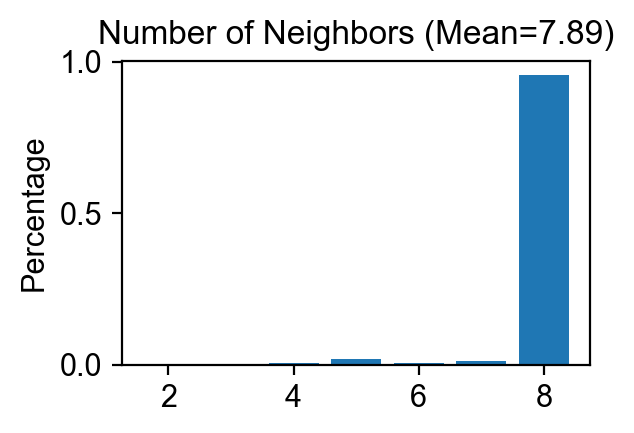

In [7]:
stv.Stats_Spatial_Net(adata)

In [8]:
adata = stv.train_STAVelo(adata, loss_type="cosine", w1 = 1, w2 = 1, random_seed=0, device = 'cuda:0')

Size of Input:  (12567, 1000)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:33<00:00, 29.58it/s]


In [9]:
stv.velocity_graph(adata, n_neighbors=2000, basis="X_pca", n_jobs=16)

        Consider computing the graph in an unbiased manner 
        on full expression space by not specifying basis.

computing velocity graph (using 16/384 cores)


  0%|          | 0/12567 [00:00<?, ?cells/s]

    finished (0:00:40) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# velocity visualization

In [10]:
#adata=sc.read("./result/adata.h5ad")

Renamed 'spatial' to convention 'X_spatial' (adata.obsm).
computing velocity embedding
    finished (0:00:02) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


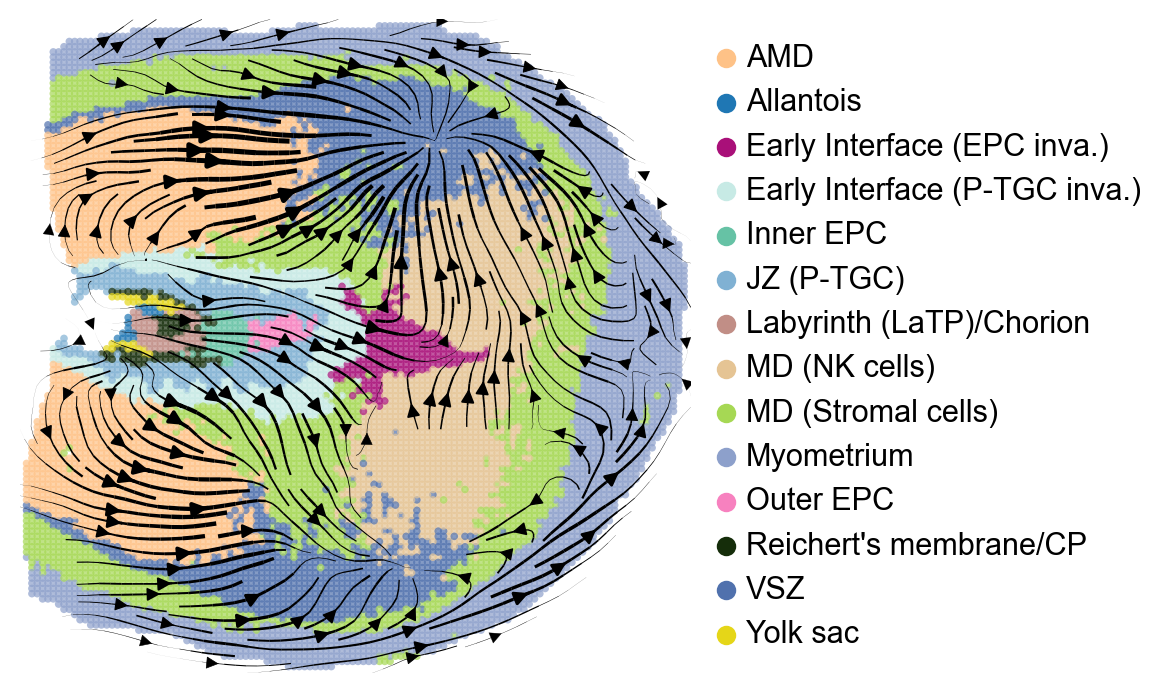

In [11]:
plt.rcParams["figure.figsize"] = (4.3, 4.3)
stv.velocity_embedding_stream(adata, basis='spatial', color="subregion", title="", legend_loc="right", alpha=0.7, size=30)

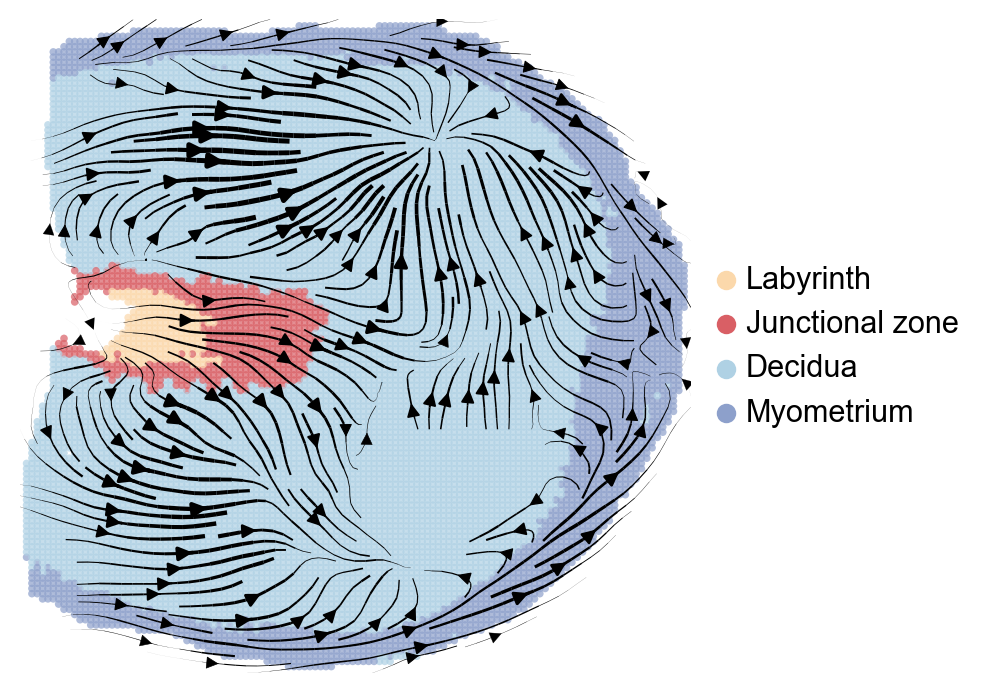

In [12]:
plt.rcParams["figure.figsize"] = (4.3, 4.3)
stv.velocity_embedding_stream(adata, basis='spatial', color="region", title="", legend_loc="right", alpha=0.7, size=30)

In [13]:
#if not os.path.exists("./result"):
#    os.makedirs("./result")
#adata.write("./result/adata.h5ad")

# UMAP

In [14]:
sc.pp.neighbors(adata, use_rep='rep_2')
sc.tl.umap(adata)

computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


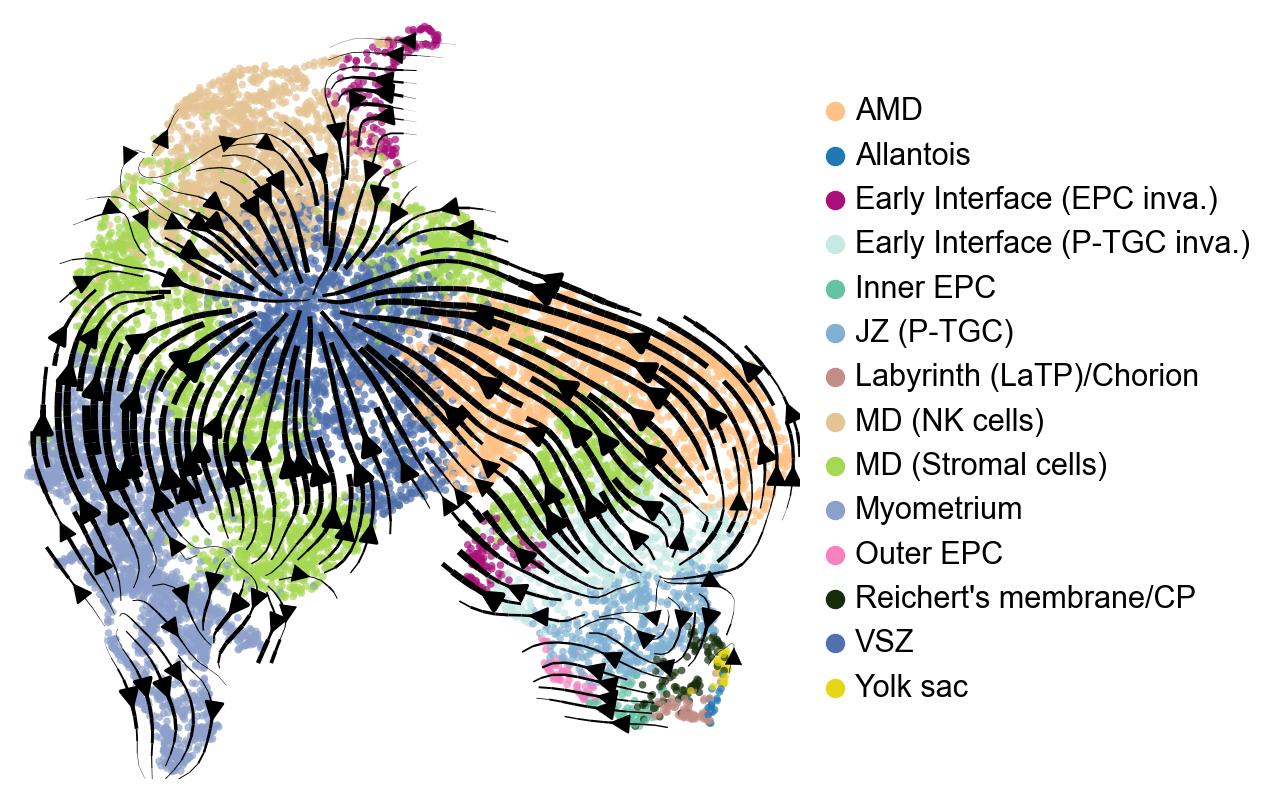

In [15]:
plt.rcParams["figure.figsize"] = (5, 5)
stv.velocity_embedding_stream(adata, basis='X_umap', color="subregion", title="", legend_loc="right", alpha=0.7, size=30, 
                              linewidth=1.5, arrow_size=1.5)

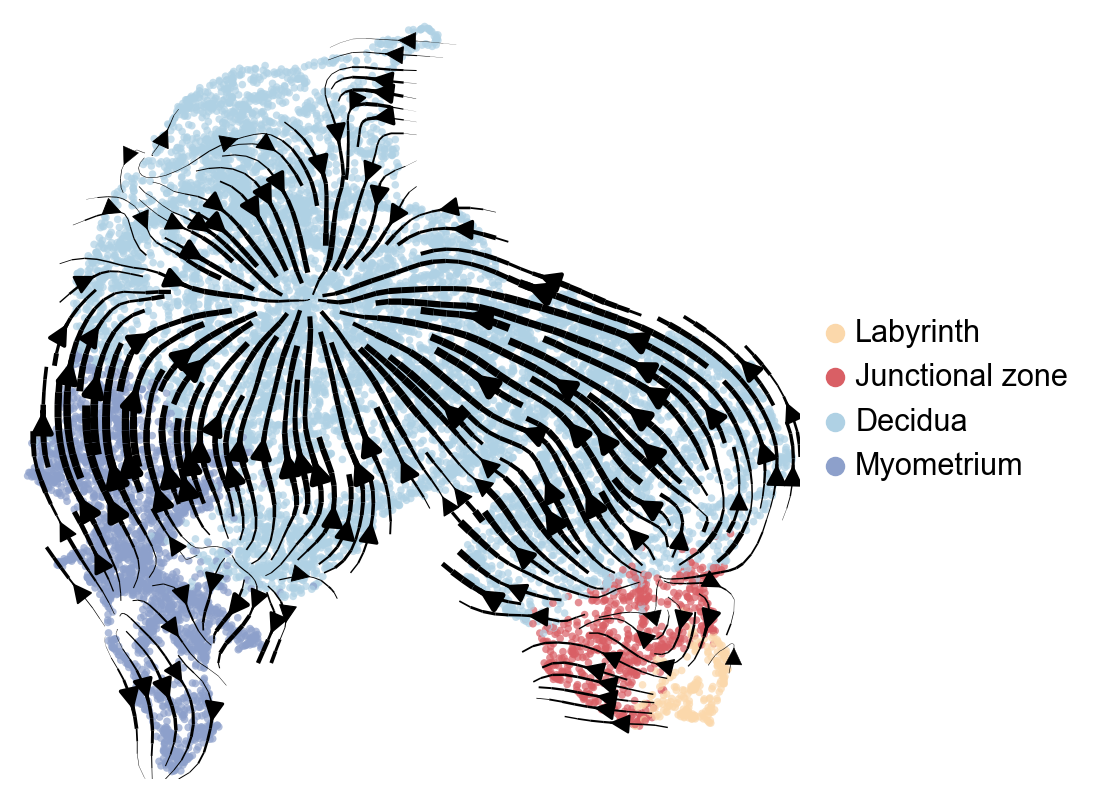

In [16]:
plt.rcParams["figure.figsize"] = (5, 5)
stv.velocity_embedding_stream(adata, basis='X_umap', color="region", title="", legend_loc="right", alpha=0.7, size=30, 
                              linewidth=1.5, arrow_size=1.5)